In [1]:
# Set workspace
import sys
import os
workspace_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Libraries

In [2]:
# Libraries
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import gpxpy

from helper_functions.gpx_to_tabular import (
    gpx_to_tabular
)

# Get data

In [3]:
# Config
years = [2024, 2025]

In [4]:
# Get local race results data for UTMB

# Dictionary | key = year
utmb_race_results_df_dict = dict()
for year in years:

    utmb_year_race_results_df = pd.read_parquet(
        os.path.join("..", "utmb_under_27h/data", f"utmb_{year}_race_results.parquet")
    )
    utmb_year_race_results_df = utmb_year_race_results_df.assign(year=year)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_race_results_df_dict[year] = utmb_year_race_results_df

# Single dataframe with all years
utmb_race_results_df = pd.concat(
    utmb_race_results_df_dict.values(),
    ignore_index=True
).reset_index(drop=True)

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [5]:
# Get sector data for UTMB

# Dictionary | key = year
utmb_sector_data_dict = dict()
for year in years:

    with open(os.path.join(f"data", f"utmb_{year}_sector_data.pkl"), "rb") as f:
        utmb_year_sector_data_dict = pickle.load(f)

    print(f"Data for year {year} fetched and loaded successfully")
    utmb_sector_data_dict[year] = utmb_year_sector_data_dict

Data for year 2024 fetched and loaded successfully
Data for year 2025 fetched and loaded successfully


In [6]:
# UTMB GPX
gpx_file_path = "utmb_2025_course.gpx"
with open(gpx_file_path, "r") as f:
    utmb_gpx = gpxpy.parse(f)

utmb_course_df = gpx_to_tabular(utmb_gpx)

Connect Race data & Sector data - Dict

In [7]:
# Dict((year, bib_number) -> sector data dataframe with race results information

runner_race_sector_data_dict = dict()
for year in years:
    utmb_race_results_year_df = utmb_race_results_df_dict[year]
    utmb_sector_data_year_dict = utmb_sector_data_dict[year]
 
    for bib_number in utmb_sector_data_year_dict.keys():
        utmb_race_results_year_bib_series = utmb_race_results_year_df.query("runner_bib_number == @bib_number").iloc[0]
        
        utmb_sector_data_year_bib_df = (
            utmb_sector_data_year_dict[bib_number]
            .assign(**utmb_race_results_year_bib_series.to_dict())
        )

        runner_race_sector_data_dict[(year, bib_number)] = utmb_sector_data_year_bib_df

In [8]:
# Full dataframe with all years and all runners and their sectors combined
dfs = []
for df in runner_race_sector_data_dict.values():
    if df is None or df.empty:
        continue
    dfs.append(df.dropna(axis=1, how="all"))

runner_race_sector_data_df = pd.concat(dfs, ignore_index=True)

# About data

Work on data

In [9]:
# Runner/Race/Year unique identifier - Runner ID
runner_race_sector_data_df = runner_race_sector_data_df.assign(
    runner_id = lambda x: x.groupby([
        "runner_bib_number",
        "race_id",
        "year",
    ]).ngroup() + 1
)

About data

In [10]:
# About data
print("About data:")
print("-------------------------------------")
print("Race IDs: {}".format(runner_race_sector_data_df["race_id"].unique()))
print("Race names: {}".format(runner_race_sector_data_df["race_name"].unique()))
print("Years: {}".format(runner_race_sector_data_df["year"].unique()))
print("Number of unique runners: {:,}".format(runner_race_sector_data_df["runner_url"].nunique()))
print("Number of unique Runner/Race/Year combinations: {:,}".format(runner_race_sector_data_df["runner_id"].nunique()))

About data:
-------------------------------------
Race IDs: ['utmb']
Race names: ['UTMB®']
Years: [2024 2025]
Number of unique runners: 5,058
Number of unique Runner/Race/Year combinations: 5,249


In [11]:
# About Sectors
print("\nAbout sectors:")
print("-------------------------------------")
print("Number of sector checpoints: {:,}".format(runner_race_sector_data_df["sector_checkpoint_id"].nunique()))
print("Sector checkpoint IDs: {}".format(runner_race_sector_data_df["sector_checkpoint_id"].unique().tolist()))

print("Do all races/years have the same number of sectors? {}".format(
    runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique().nunique() == 1
))

sector_sets = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].apply(lambda s: frozenset(s.unique()))
print("Do all races/years have the same sector IDs? {}".format(
    sector_sets.nunique() == 1
))

expected_sector_count = runner_race_sector_data_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
runner_sector_counts = runner_race_sector_data_df.groupby(["race_id", "year", "runner_bib_number"])["sector_checkpoint_id"].nunique()
print("Do all runners have all of the sectors? {}".format(
    runner_sector_counts.groupby(["race_id", "year"]).min().eq(expected_sector_count).all()
))


About sectors:
-------------------------------------
Number of sector checpoints: 28
Sector checkpoint IDs: [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 18, 19, 20, 22, 23, 24, 27, 30, 31, 33, 34, 35, 44, 144]
Do all races/years have the same number of sectors? False
Do all races/years have the same sector IDs? False
Do all runners have all of the sectors? True


Sector data work
- sector_race_time_at_checkpoint - formatted cumulative race time at sector (checkpoint) arrival
- sector_time_seconds - cumulative race time at sector (checkpoint) arrival
- sector_time - previous sector time (time for the segment that ended at this checkpoint) - excluding rest at the previous checkpoint.
- sector_rest_time / sector_rest_time_seconds - checkpoint stop time, but some rows may be special rest-only checkpoint rows.
- Row (j) means sector from previous checkpoint to current checkpoint and not sector starting at current checkpoint

In [12]:
# Sector data display 
sector_cols = runner_race_sector_data_df.columns[
    runner_race_sector_data_df.columns.str.contains("sector")
]
runner_race_sector_data_df.loc[:, ["runner_id"] + sector_cols.tolist()]

,runner_id,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_rest_time_seconds,sector_speed_kmh,sector_pace_min_per_km,sector_time_seconds,sector_time,sector_race_time_at_checkpoint,sector_checkpoint_rank,sector_checkpoint_rank_change,sector_predicted_time,sector_rest_time
0,1,0,None,2024-08-30T16:01:52.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,2024-08-30T17:14:33.620Z,2024-08-30T17:14:33.620Z,NaN,10.89,5.51,4361.62,1:12:42,1:12:42,21.0,NaN,NaN,NaN
2,1,3,2024-08-30T17:54:10.170Z,2024-08-30T17:54:10.170Z,NaN,12.86,4.67,6738.17,0:39:37,1:52:18,26.0,5.0,2024-08-30T18:00:04.000Z,NaN
3,1,4,2024-08-30T18:48:40.530Z,2024-08-30T18:48:40.530Z,NaN,10.63,5.64,10008.53,0:54:30,2:46:49,18.0,-8.0,2024-08-30T18:50:34.000Z,NaN
4,1,5,2024-08-30T19:11:01.290Z,2024-08-30T19:11:01.290Z,NaN,11.49,5.22,11349.29,0:22:21,3:09:09,17.0,-1.0,2024-08-30T19:11:34.000Z,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141989,4917,33,2025-08-30T22:32:33.000Z,2025-08-30T22:32:33.000Z,NaN,2.90,20.67,110853.00,1:22:41,30:47:33,556.0,-37.0,2025-08-30T22:29:48.000Z,NaN
141990,4917,34,2025-08-31T00:30:10.000Z,2025-08-31T00:30:10.000Z,NaN,4.15,14.45,117910.00,1:57:37,32:45:10,561.0,5.0,2025-08-31T00:18:22.000Z,NaN
141991,4917,35,2025-08-31T00:44:09.000Z,2025-08-31T00:44:09.000Z,839.0,NaN,NaN,118749.00,0:13:59,32:59:09,566.0,5.0,2025-08-31T00:30:10.000Z,0:13:59
141992,4917,44,2025-08-31T04:25:06.000Z,2025-08-31T04:25:06.000Z,NaN,3.06,19.59,132006.00,3:40:57,36:40:06,563.0,-3.0,2025-08-31T04:07:09.000Z,NaN


In [13]:
# Sector diagnostic

sector_clean_check_df = (
    runner_race_sector_data_df
    .sort_values(["runner_id", "sector_checkpoint_id"])
    .assign(
        sector_arrival_time_dt=lambda df: pd.to_datetime(df["sector_arrival_time"], errors="coerce"),
        sector_departure_time_dt=lambda df: pd.to_datetime(df["sector_departure_time"], errors="coerce"),

        previous_sector_checkpoint_id=lambda df: (
            df.groupby("runner_id")["sector_checkpoint_id"].shift(1)
        ),
        previous_sector_arrival_time_dt=lambda df: (
            df.groupby("runner_id")["sector_arrival_time_dt"].shift(1)
        ),
        previous_sector_departure_time_dt=lambda df: (
            df.groupby("runner_id")["sector_departure_time_dt"].shift(1)
        ),

        sector_time_from_field_seconds=lambda df: (
            pd.to_timedelta(df["sector_time"]).dt.total_seconds()
        ),
        sector_race_time_at_checkpoint_seconds=lambda df: (
            pd.to_timedelta(df["sector_race_time_at_checkpoint"]).dt.total_seconds()
        ),
        sector_time_from_cumulative_diff_seconds=lambda df: (
            df.groupby("runner_id")["sector_time_seconds"].diff()
        ),
        sector_time_from_arrival_diff_seconds=lambda df: (
            df["sector_arrival_time_dt"] - df["previous_sector_arrival_time_dt"]
        ).dt.total_seconds(),
        sector_time_from_previous_departure_seconds=lambda df: (
            df["sector_arrival_time_dt"] - df["previous_sector_departure_time_dt"]
        ).dt.total_seconds(),
        sector_rest_time_from_field_seconds=lambda df: (
            pd.to_timedelta(df["sector_rest_time"]).dt.total_seconds()
        ),
        sector_rest_time_from_timestamp_seconds=lambda df: (
            df["sector_departure_time_dt"] - df["sector_arrival_time_dt"]
        ).dt.total_seconds(),
    )
)

display(
    sector_clean_check_df[
        [
            "runner_id",
            "previous_sector_checkpoint_id",
            "sector_checkpoint_id",
            "sector_arrival_time",
            "sector_departure_time",
            "sector_time",
            "sector_time_seconds",
            "sector_time_from_field_seconds",
            "sector_time_from_cumulative_diff_seconds",
            "sector_time_from_arrival_diff_seconds",
            "sector_time_from_previous_departure_seconds",
            "sector_rest_time",
            "sector_rest_time_seconds",
            "sector_rest_time_from_field_seconds",
            "sector_rest_time_from_timestamp_seconds",
        ]
    ].head(40)
)

sector_clean_check_summary_df = (
    sector_clean_check_df
    .assign(
        diff_field_vs_cumulative_diff=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_cumulative_diff_seconds"]
        ),
        diff_field_vs_arrival_diff=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_arrival_diff_seconds"]
        ),
        diff_field_vs_previous_departure=lambda df: (
            df["sector_time_from_field_seconds"]
            - df["sector_time_from_previous_departure_seconds"]
        ),
        diff_rest_field_vs_timestamp=lambda df: (
            df["sector_rest_time_from_field_seconds"]
            - df["sector_rest_time_from_timestamp_seconds"]
        ),
    )
    [
        [
            "diff_field_vs_cumulative_diff",
            "diff_field_vs_arrival_diff",
            "diff_field_vs_previous_departure",
            "diff_rest_field_vs_timestamp",
        ]
    ]
    .describe()
)

display(sector_clean_check_summary_df)

,runner_id,previous_sector_checkpoint_id,sector_checkpoint_id,sector_arrival_time,sector_departure_time,sector_time,sector_time_seconds,sector_time_from_field_seconds,sector_time_from_cumulative_diff_seconds,sector_time_from_arrival_diff_seconds,sector_time_from_previous_departure_seconds,sector_rest_time,sector_rest_time_seconds,sector_rest_time_from_field_seconds,sector_rest_time_from_timestamp_seconds
0,1,NaN,0,None,2024-08-30T16:01:52.000Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,0.0,2,2024-08-30T17:14:33.620Z,2024-08-30T17:14:33.620Z,1:12:42,4361.62,4362.0,NaN,NaN,4361.62,NaN,NaN,NaN,0.000
2,1,2.0,3,2024-08-30T17:54:10.170Z,2024-08-30T17:54:10.170Z,0:39:37,6738.17,2377.0,2376.55,2376.55,2376.55,NaN,NaN,NaN,0.000
3,1,3.0,4,2024-08-30T18:48:40.530Z,2024-08-30T18:48:40.530Z,0:54:30,10008.53,3270.0,3270.36,3270.36,3270.36,NaN,NaN,NaN,0.000
4,1,4.0,5,2024-08-30T19:11:01.290Z,2024-08-30T19:11:01.290Z,0:22:21,11349.29,1341.0,1340.76,1340.76,1340.76,NaN,NaN,NaN,0.000
5,1,5.0,6,2024-08-30T19:46:31.590Z,2024-08-30T19:46:31.590Z,0:35:30,13479.59,2130.0,2130.30,2130.30,2130.30,NaN,NaN,NaN,0.000
6,1,6.0,7,2024-08-30T20:44:16.000Z,2024-08-30T20:44:16.000Z,0:57:44,16944.00,3464.0,3464.41,3464.41,3464.41,NaN,NaN,NaN,0.000
7,1,7.0,8,2024-08-30T21:09:39.110Z,2024-08-30T21:12:02.040Z,0:25:23,18467.11,1523.0,1523.11,1523.11,1523.11,0:02:23,142.93,143.0,142.930
8,1,8.0,9,2024-08-30T22:42:06.000Z,2024-08-30T22:42:06.000Z,1:30:04,24014.00,5404.0,5546.89,5546.89,5403.96,NaN,NaN,NaN,0.000
9,1,9.0,11,2024-08-30T23:34:43.550Z,2024-08-30T23:34:43.550Z,0:52:38,27171.55,3158.0,3157.55,3157.55,3157.55,NaN,NaN,NaN,0.000


,diff_field_vs_cumulative_diff,diff_field_vs_arrival_diff,diff_field_vs_previous_departure,diff_rest_field_vs_timestamp
count,105743.000000,105743.000000,110929.000000,30151.000000
mean,-251.854165,-251.854165,0.002423,462.531017
std,700.710572,700.710572,0.212303,1073.040192
min,-16420.940000,-16420.940000,-0.490000,-0.490000
25%,-0.460000,-0.460000,-0.030000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.040000,24.000000
max,0.500000,0.500000,0.500000,12701.000000


In [14]:
# "Clean" sector data columns

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .sort_values(["runner_id", "sector_checkpoint_id"])
    .assign(

        # Checkpoint timing
        sector_arrival_time_dt = lambda df: pd.to_datetime(
            df["sector_arrival_time"],
            errors="coerce",
        ),
        sector_departure_time_dt = lambda df: pd.to_datetime(
            df["sector_departure_time"],
            errors="coerce",
        ),

        # Cumulative race time at checkpoint arrival
        sector_race_time_at_checkpoint_min = lambda df: (
            df["sector_time_seconds"] / 60
        ),

        # Movement-ish time: previous checkpoint departure -> current checkpoint arrival
        sector_time_moving_min = lambda df: (
            pd.to_timedelta(df["sector_time"]).dt.total_seconds() / 60
        ),

        # Race-clock elapsed time: previous checkpoint arrival -> current checkpoint arrival
        # This includes rest at the previous checkpoint.
        sector_time_elapsed_min = lambda df: (
            (df.groupby("runner_id")["sector_time_seconds"].diff() / 60).fillna(df["sector_time_moving_min"])
        ),

        # Rest/stop time at checkpoint
        sector_rest_time_min = lambda df: (
            (pd.to_timedelta(df["sector_rest_time"]).dt.total_seconds() / 60).fillna(0)
        ),
    )
    .assign(
        # Rest at previous checkpoint + movement into current checkpoint
        sector_time_full_start_rest_min = lambda df: (
            df.groupby("runner_id")["sector_rest_time_min"].shift(1).fillna(0) + df["sector_time_moving_min"]
        ),
        # Movement into current checkpoint + rest at current checkpoint
        sector_time_full_end_rest_min = lambda df: (
            df["sector_time_moving_min"] + df["sector_rest_time_min"]
        ),
        # Movement only: previous checkpoint departure -> current checkpoint arrival
        sector_time_full_no_rest_min = lambda df: (
            df["sector_time_moving_min"]
        )
    )
    .assign(
        # Useful rest share feature
        sector_rest_time_share_start_rest = lambda df: (
            df["sector_rest_time_min"] / df["sector_time_full_start_rest_min"]
        ),
        sector_rest_time_end_share = lambda df: (
            df["sector_rest_time_min"] / df["sector_time_full_end_rest_min"]
        ),
    )
    .assign(
        # Runner-level sector distance estimate [km]
        sector_distance_km_runner_estimate = lambda df: (
            df["sector_time_moving_min"]
            / df["sector_pace_min_per_km"]
        ),
        # Sector distance [km]: median estimate within race/year/sector
        sector_distance_km = lambda df: (
            df.groupby(
                ["race_id", "year", "sector_checkpoint_id"]
            )["sector_distance_km_runner_estimate"]
            .transform("median")
        ),
        # Cumulative sector distance [km] within runner
        cumulative_sector_distance_km = lambda df: (
            df.groupby("runner_id")["sector_distance_km"].cumsum()
        ),
    )
    # Remove start rows
    # .loc[lambda df: df["sector_time_moving_min"].notna()]
    .loc[lambda df: df["sector_checkpoint_id"] != 0]
    .reset_index(drop=True)
)

In [15]:
# Identify rest only sectors
rest_only_checkpoint_check_df = (
    runner_race_sector_data_df
    .loc[
        lambda df: (
            df["runner_is_finisher"]
            & df["sector_time_moving_min"].notna()
            & (df["sector_checkpoint_id"] != 0)
        )
    ]
    .groupby(["race_id", "year", "sector_checkpoint_id"], as_index = False,)
    .agg(
        number_of_observations = ("runner_id", "size"),
        missing_pace_share = (
            "sector_pace_min_per_km",
            lambda x: x.isna().mean(),
        ),
        median_sector_time_min = (
            "sector_time_moving_min",
            "median",
        ),
        median_rest_time_min = (
            "sector_rest_time_min",
            "median",
        ),
    )
    .assign(
        checkpoint_is_rest_only = lambda df: (
            (df["missing_pace_share"] >= 0.95)
            & (df["median_rest_time_min"] > 0)
        )
    )
)

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .merge(
        rest_only_checkpoint_check_df[
            [
                "race_id",
                "year",
                "sector_checkpoint_id",
                "checkpoint_is_rest_only",
            ]
        ],
        on = ["race_id", "year", "sector_checkpoint_id"],
        how = "left",
        validate = "m:1",
    )
    .assign(
        sector_is_rest_only = lambda df: (
            df["checkpoint_is_rest_only"].fillna(False)
        ),
        sector_time_moving_min = lambda df: np.where(df["sector_is_rest_only"], 0, df["sector_time_moving_min"]),
        sector_distance_km_runner_estimate = lambda df: np.where(df["sector_is_rest_only"], 0, df["sector_time_moving_min"] / df["sector_pace_min_per_km"]),
        sector_distance_km = lambda df: (
            df
            .groupby(["race_id", "year", "sector_checkpoint_id"])
            ["sector_distance_km_runner_estimate"].transform("median")
        ),
        cumulative_sector_distance_km = lambda df: (
            df.groupby("runner_id")["sector_distance_km"].cumsum()
        ),
    )
    .drop(columns = "checkpoint_is_rest_only")
)

# Total race distance after rest-only sectors are corrected
total_distance_km_by_year = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby(["runner_id", "year"])["sector_distance_km"]
    .sum()
    .reset_index()
    .groupby("year")["sector_distance_km"]
    .mean()
)

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        # Total race distance
        total_distance_km = lambda df: df["year"].map(total_distance_km_by_year),

        # Sector start and end distance [km]
        sector_start_distance_km = lambda df: (
            df["cumulative_sector_distance_km"] - df["sector_distance_km"]
        ),
        sector_end_distance_km = lambda df: (
            df["cumulative_sector_distance_km"]
        ),

        # Sector distance relative to total race distance
        relative_sector_distance = lambda df: (
            df["sector_distance_km"] / df["total_distance_km"]
        ).clip(lower = 0, upper = 1),
        relative_cumulative_sector_distance = lambda df: (
            df["cumulative_sector_distance_km"] / df["total_distance_km"]
        ).clip(lower = 0, upper = 1),
    )
    .assign(
        # Relative sector start and end distance
        relative_sector_start_distance = lambda df: (
            df["relative_cumulative_sector_distance"] - df["relative_sector_distance"]
        ).clip(lower = 0, upper = 1),
        relative_sector_end_distance = lambda df: (
            df["relative_cumulative_sector_distance"]
        ),
    )
)

# Assert
finisher_max = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby("runner_id")["relative_cumulative_sector_distance"]
    .max()
)
assert np.allclose(finisher_max, 1.0, atol = 1e-3), "Relative cumulative sector distance does not end at 1 for every finisher."

In [16]:
finisher_max = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby("runner_id")["relative_cumulative_sector_distance"]
    .max()
)

In [17]:
runner_race_sector_data_df.query("runner_id == 2522")

,runner_bib_number,runner_name,runner_age,runner_gender,runner_overall_index,runner_category,runner_club,sector_checkpoint_id,sector_arrival_time,sector_departure_time,...,sector_distance_km,cumulative_sector_distance_km,sector_is_rest_only,total_distance_km,sector_start_distance_km,sector_end_distance_km,relative_sector_distance,relative_cumulative_sector_distance,relative_sector_start_distance,relative_sector_end_distance
65473,1404,Louis PECH,32.0,H,531.0,20-34M,,2,None,None,...,14.560041,14.560041,False,175.400214,0.000000,14.560041,0.083010,0.083010,0.000000,0.083010
65474,1404,Louis PECH,32.0,H,531.0,20-34M,,3,None,None,...,8.490028,23.050070,False,175.400214,14.560041,23.050070,0.048404,0.131414,0.083010,0.131414
65475,1404,Louis PECH,32.0,H,531.0,20-34M,,4,2025-08-29T20:15:32.000Z,2025-08-29T20:15:32.000Z,...,9.659864,32.709934,False,175.400214,23.050070,32.709934,0.055073,0.186487,0.131414,0.186487
65476,1404,Louis PECH,32.0,H,531.0,20-34M,,6,2025-08-29T22:04:09.000Z,2025-08-29T22:04:14.000Z,...,8.630009,41.339943,False,175.400214,32.709934,41.339943,0.049202,0.235689,0.186487,0.235689
65477,1404,Louis PECH,32.0,H,531.0,20-34M,,7,2025-08-29T23:51:08.000Z,2025-08-29T23:51:08.000Z,...,5.830004,47.169948,False,175.400214,41.339943,47.169948,0.033238,0.268928,0.235689,0.268928
65478,1404,Louis PECH,32.0,H,531.0,20-34M,,8,2025-08-30T00:47:47.000Z,2025-08-30T00:56:13.000Z,...,5.280000,52.449948,False,175.400214,47.169948,52.449948,0.030103,0.299030,0.268928,0.299030
65479,1404,Louis PECH,32.0,H,531.0,20-34M,,9,2025-08-30T03:30:44.000Z,2025-08-30T03:30:44.000Z,...,10.789980,63.239928,False,175.400214,52.449948,63.239928,0.061516,0.360546,0.299030,0.360546
65480,1404,Louis PECH,32.0,H,531.0,20-34M,,11,2025-08-30T04:19:48.000Z,2025-08-30T04:19:48.000Z,...,4.870184,68.110112,False,175.400214,63.239928,68.110112,0.027766,0.388313,0.360546,0.388313
65481,1404,Louis PECH,32.0,H,531.0,20-34M,,12,2025-08-30T05:24:14.000Z,2025-08-30T05:24:14.000Z,...,3.989994,72.100106,False,175.400214,68.110112,72.100106,0.022748,0.411061,0.388313,0.411061
65482,1404,Louis PECH,32.0,H,531.0,20-34M,,13,2025-08-30T06:08:01.000Z,2025-08-30T06:08:01.000Z,...,4.590060,76.690166,False,175.400214,72.100106,76.690166,0.026169,0.437230,0.411061,0.437230


In [18]:
finisher_max.sort_values()

runner_id
5230    1.0
5234    1.0
5240    1.0
5241    1.0
5242    1.0
       ... 
73      1.0
78      1.0
81      1.0
82      1.0
1       1.0
Name: relative_cumulative_sector_distance, Length: 3425, dtype: float64

In [19]:
# Connect UTMB Course GPX data to sector data - Calculate some new features for each sector

sector_boundaries_df = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby("sector_checkpoint_id")
    .agg(
        sector_distance_km = ("sector_distance_km", "median"),
        cumulative_sector_distance_km = ("cumulative_sector_distance_km", "median"),
    )
    .reset_index()
    .sort_values("cumulative_sector_distance_km")
    .reset_index(drop=True)
    .assign(
        sector_start_distance_m = lambda df: (
            df["cumulative_sector_distance_km"]
            .shift(1)
            .fillna(0)
            * 1_000
        ),
        sector_end_distance_m = lambda df: (
            df["cumulative_sector_distance_km"] * 1_000
        ),
    )
    .reset_index(names = "sector_boundary_index")
)

sector_end_distances_m = sector_boundaries_df["sector_end_distance_m"].to_numpy()

course_sector_df = (
    utmb_course_df
    .sort_values("total_distance_2d_m")
    .reset_index(drop = True)
    .assign(
        sector_boundary_index = lambda df: np.searchsorted(
            sector_end_distances_m,
            df["total_distance_2d_m"],
            side = "left",
        )
    )
    .assign(
        sector_boundary_index = lambda df: df["sector_boundary_index"].clip(upper = len(sector_boundaries_df) - 1)
    )
)

course_sector_df = (
    course_sector_df
    .merge(
        sector_boundaries_df,
        on = "sector_boundary_index",
        how = "left",
        validate = "m:1",
    )
)

course_sector_agg_df = (
    course_sector_df
    .groupby("sector_checkpoint_id")
    .agg(
        sector_elevation_gain_m = ("point_elevation_gain_m", "sum"),
        sector_elevation_loss_m = ("point_elevation_loss_m", "sum")
    )
    .reset_index()
)

In [20]:
# Add additional sector data to "main" data and calculate some new features

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .merge(
        course_sector_agg_df,
        on = "sector_checkpoint_id",
        how = "left",
        validate = "m:1"
    )
    .assign(
        # Cumulative sector elevation gain [m] within runner
        cumulative_sector_elevation_gain_m = lambda df: (
            df.groupby("runner_id")["sector_elevation_gain_m"].cumsum()
        ),
        # Cumulative sector elevation loss [m] within runner
        cumulative_sector_elevation_loss_m = lambda df: (
            df.groupby("runner_id")["sector_elevation_loss_m"].cumsum()
        ),

        # Cumulative elevation gain at sector start and end [m]
        sector_start_elevation_gain_m = lambda df: (
            df["cumulative_sector_elevation_gain_m"] - df["sector_elevation_gain_m"]
        ),
        sector_end_elevation_gain_m = lambda df: (
            df["cumulative_sector_elevation_gain_m"]
        ),

        # Cumulative elevation loss at sector start and end [m]
        sector_start_elevation_loss_m = lambda df: (
            df["cumulative_sector_elevation_loss_m"] - df["sector_elevation_loss_m"]
        ),
        sector_end_elevation_loss_m = lambda df: (
            df["cumulative_sector_elevation_loss_m"]
        ),
    )
)

# Total race elevation gain and loss (year specific)
total_gain_loss_m_by_year = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby(["runner_id", "year"])[["sector_elevation_gain_m", "sector_elevation_loss_m"]]
    .sum()
    .reset_index()
    .groupby("year")[["sector_elevation_gain_m", "sector_elevation_loss_m"]]
    .mean()
)

runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        # Total race elevation gain & loss
        total_elevation_gain_m = lambda df: df["year"].map(
            total_gain_loss_m_by_year["sector_elevation_gain_m"]
        ),
        total_elevation_loss_m = lambda df: df["year"].map(
            total_gain_loss_m_by_year["sector_elevation_loss_m"]
        ),
        # Relative sector elevation gain & loss [%]
        relative_sector_elevation_gain = lambda df: (
            df["sector_elevation_gain_m"] / df["total_elevation_gain_m"]
        ).clip(lower = 0, upper = 1),
        relative_sector_elevation_loss = lambda df: (
            df["sector_elevation_loss_m"] / df["total_elevation_loss_m"]
        ).clip(lower = 0, upper = 1),
    )
)

# Adjust so it sums to 1 (only for finishers)
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        relative_cumulative_sector_elevation_gain = lambda df: np.where(
            df["runner_is_finisher"] == 1,
            df["cumulative_sector_elevation_gain_m"]
            / df.groupby("runner_id")["cumulative_sector_elevation_gain_m"].transform("max"),
            np.nan,
        ),
        relative_cumulative_sector_elevation_loss = lambda df: np.where(
            df["runner_is_finisher"] == 1,
            df["cumulative_sector_elevation_loss_m"]
            / df.groupby("runner_id")["cumulative_sector_elevation_loss_m"].transform("max"),
            np.nan,
        ),
    )
    .assign(
        relative_cumulative_sector_elevation_gain = lambda df: df["relative_cumulative_sector_elevation_gain"].clip(lower = 0, upper = 1),
        relative_cumulative_sector_elevation_loss = lambda df: df["relative_cumulative_sector_elevation_loss"].clip(lower = 0, upper = 1),

        # Relative cumulative elevation gain at sector start and end
        relative_sector_start_elevation_gain = lambda df: (
            df["relative_cumulative_sector_elevation_gain"] - df["relative_sector_elevation_gain"]
        ).clip(lower = 0, upper = 1),
        relative_sector_end_elevation_gain = lambda df: (
            df["relative_cumulative_sector_elevation_gain"]
        ),

        # Relative cumulative elevation loss at sector start and end
        relative_sector_start_elevation_loss = lambda df: (
            df["relative_cumulative_sector_elevation_loss"] - df["relative_sector_elevation_loss"]
        ).clip(lower = 0, upper = 1),
        relative_sector_end_elevation_loss = lambda df: (
            df["relative_cumulative_sector_elevation_loss"]
        ),
    )
)

# Assert
finisher_max = (
    runner_race_sector_data_df
    .query("runner_is_finisher == 1")
    .groupby("runner_id")[["relative_cumulative_sector_elevation_gain", "relative_cumulative_sector_elevation_loss"]]
    .max()
)

assert np.allclose(finisher_max["relative_cumulative_sector_elevation_gain"], 1.0, atol=1e-2)
assert np.allclose(finisher_max["relative_cumulative_sector_elevation_loss"], 1.0, atol=1e-2)

Sector rows are arrival-based:
- Each row describes the segment from the previous checkpoint to this checkpoint.
- sector_time_moving_min - previous checkpoint departure -> current checkpoint arrival (excludes rest at the previous checkpoint)
- sector_time_elapsed_min - previous checkpoint arrival -> current checkpoint arrival (includes rest at the previous checkpoint plus movement to current checkpoint)
- sector_rest_time_min - current checkpoint arrival -> current checkpoint departure (rest/stop time at the current checkpoint)
- row with sector_checkpoint_id = 9 describes the segment: previous checkpoint -> checkpoint 9

Rests:
- arrival_time - when runner reaches the checkpoint/hut
- departure_time - when runner leaves the checkpoint/hut
- rest_time - departure_time - arrival_time
- the runner “goes through” the checkpoint at arrival, then may rest, then departs
- for row j:
    - previous checkpoint departure -> current checkpoint arrival --> sector_time_moving_min
    - current checkpoint arrival -> current checkpoint departure --> sector_rest_time_min

Where do we assign the rest time analytically?
- a) rest belongs to the sector ending - the sector includes arriving at the rest stop and dealing with the rest stop before continuing [sector_full_time_current_rest = sector_time_moving_min + sector_rest_time_min]
- b) rest belongs to the next sector - full sector j+1 = rest at checkpoint j + movement from checkpoint j to checkpoint j+1 [sector_time_elapsed_min = previous checkpoint rest + movement into current checkpoint]
- c) only moving time without rest tme

Use:
- sector_time_moving_min as the main movement-sector time, 
- sector_time_elapsed_min if rest at the previous checkpoint should count, 
- and sector_rest_time_min/share as separate rest-strategy features.

Other data work

In [21]:
# Sector IDs: 1-max, not "random" values (Race/Year specific)
runner_race_sector_data_df = (
    runner_race_sector_data_df
    .assign(
        sector_number = lambda x: x
        .groupby(["race_id", "year"])["sector_checkpoint_id"]
        .rank(method="dense", ascending=True)
        .astype(int)
    )
)

# Sanity check
check_df = (
    runner_race_sector_data_df[["race_id", "year", "sector_checkpoint_id", "sector_number"]]
    .drop_duplicates()
)

assert (
    check_df.groupby(["race_id", "year"])["sector_checkpoint_id"].nunique()
    == check_df.groupby(["race_id", "year"])["sector_number"].nunique()
).all(), "Sector checkpoint mapping is not 1-to-1 within at least one race/year."

assert (
    check_df.groupby(["race_id", "year"])["sector_number"].min() == 1
).all(), "Sector checkpoint numbering does not start at 1 for at least one race/year."

# Assign to original column name
# runner_race_sector_data_df = (
#     runner_race_sector_data_df
#     .assign(sector_checkpoint_id = lambda x: x["sector_number"])
#     .drop(columns=["sector_number"])
# )

In [22]:
# How are DNF runners represented after their final reached checkpoint? --> They have missing values for all sectors after DNF race time
runner_race_sector_data_dnf_df = runner_race_sector_data_df.loc[~runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()
runner_race_sector_data_finisher_df = runner_race_sector_data_df.loc[runner_race_sector_data_df["runner_is_finisher"]].reset_index(drop=True).copy()

# Race Time Normalization - Finishers

Estimate expected runner race time based on UTMB index & Race year: T ~ UTMB_index + Race_year + UTMB_index:Race_year

In [23]:
# Data - one row per runner/year
df_race_time_normalization_estimation = (
    runner_race_sector_data_finisher_df
    .drop_duplicates(subset=["runner_id"])
    [["runner_id", "runner_race_time_hours", "runner_overall_index", "year"]]
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [24]:
# Model - Fit & Predict

# Fit 
model_race_time_norm = smf.ols(
    formula = "runner_race_time_hours ~ runner_overall_index * C(year)",
    data = df_race_time_normalization_estimation,
)
fit_race_time_norm = model_race_time_norm.fit()

# Predict & store predictions
y_pred_race_time_norm = fit_race_time_norm.predict(df_race_time_normalization_estimation)
df_race_time_normalization_estimation["runner_race_time_hours_pred"] = y_pred_race_time_norm

In [25]:
# Coefficients
coef_race_time_norm_df = (
    pd.DataFrame({
        "coef": fit_race_time_norm.params,
        "std_err": fit_race_time_norm.bse,
        "p_value": fit_race_time_norm.pvalues,
        "ci_lower": fit_race_time_norm.conf_int()[0],
        "ci_upper": fit_race_time_norm.conf_int()[1],
    })
    .reset_index(names="term")
)

coef_race_time_norm_df

,term,coef,std_err,p_value,ci_lower,ci_upper
0,Intercept,69.630598,0.480596,0.000000,68.688313,70.572884
1,C(year)[T.2025],0.034116,0.677748,0.959856,-1.294717,1.362949
2,runner_overall_index,-0.053391,0.000827,0.000000,-0.055014,-0.051769
3,runner_overall_index:C(year)[T.2025],-0.000431,0.001177,0.714486,-0.002738,0.001877


Model diagnostics

In [26]:
# Calculate absolute race time residual: Expected - Actual
df_race_time_normalization_estimation = (
    df_race_time_normalization_estimation
    .assign(
        runner_race_time_hours_residual_abs = lambda df: (
            df["runner_race_time_hours_pred"] - df["runner_race_time_hours"]
        )
    )
)

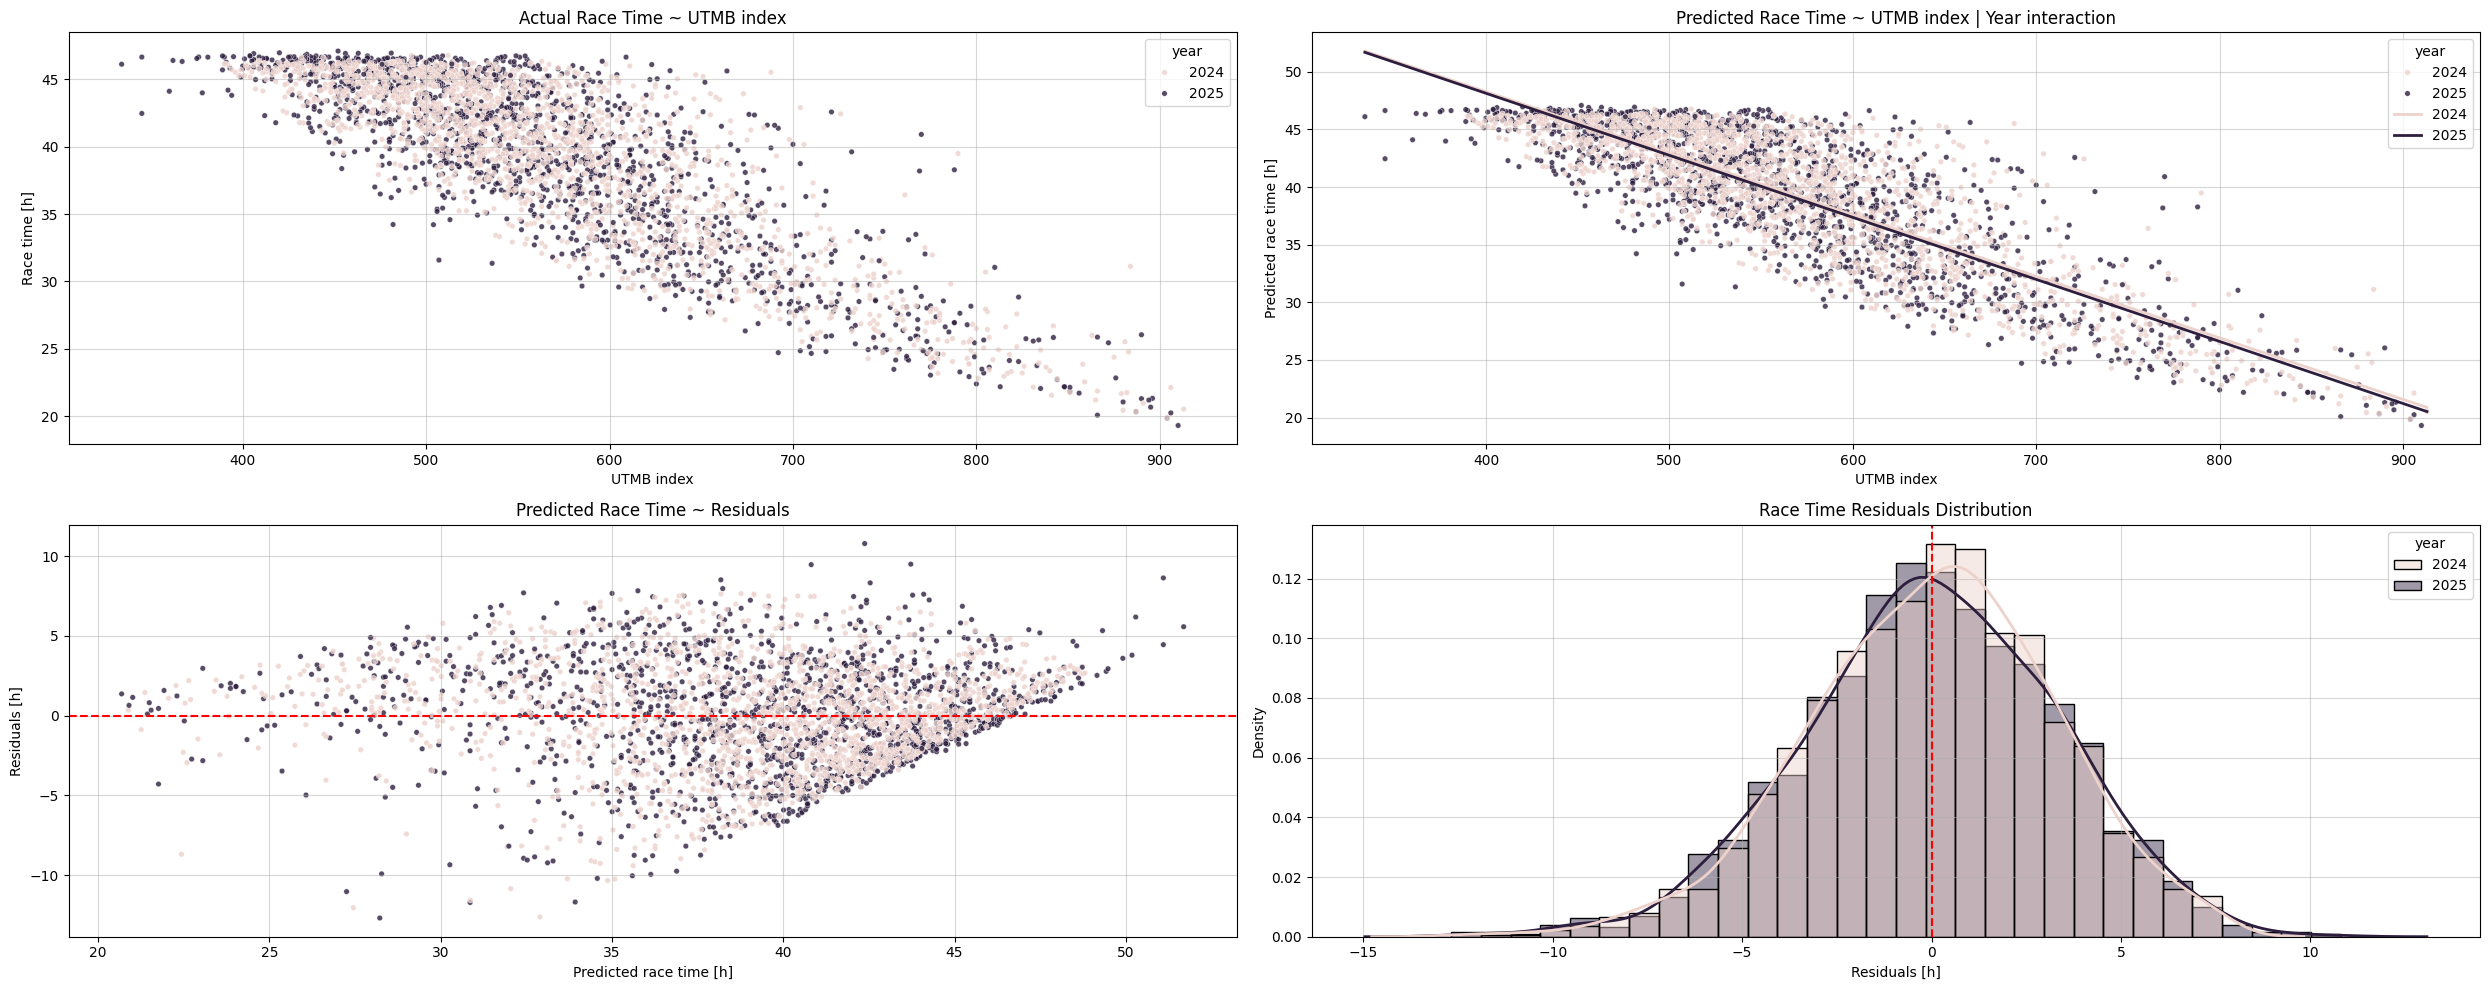

In [27]:
# Model diagnostic

fig, ax = plt.subplots(2, 2, figsize=(25, 10))

# Prediction grid for model lines
utmb_index_grid = np.linspace(
    df_race_time_normalization_estimation["runner_overall_index"].min(),
    df_race_time_normalization_estimation["runner_overall_index"].max(),
    100,
)

pred_grid_df = pd.concat(
    [
        pd.DataFrame({
            "runner_overall_index": utmb_index_grid,
            "year": year,
        })
        for year in sorted(df_race_time_normalization_estimation["year"].unique())
    ],
    ignore_index=True,
)

pred_grid_df = pred_grid_df.assign(
    runner_race_time_hours_pred=fit_race_time_norm.predict(pred_grid_df)
)

# Actual Race Time ~ UTMB index
ax[0, 0].set_title("Actual Race Time ~ UTMB index")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_overall_index",
    y="runner_race_time_hours",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[0, 0],
)
ax[0, 0].set_xlabel("UTMB index")
ax[0, 0].set_ylabel("Race time [h]")

# Model prediction lines by year
ax[0, 1].set_title("Predicted Race Time ~ UTMB index | Year interaction")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_overall_index",
    y="runner_race_time_hours",
    hue="year",
    s=16,
    alpha=0.8,
    ax=ax[0, 1],
)
sns.lineplot(
    data=pred_grid_df,
    x="runner_overall_index",
    y="runner_race_time_hours_pred",
    hue="year",
    # color="black",
    linewidth=2,
    ax=ax[0, 1],
)
ax[0, 1].set_xlabel("UTMB index")
ax[0, 1].set_ylabel("Predicted race time [h]")

# Predicted values vs. residuals
ax[1, 0].set_title("Predicted Race Time ~ Residuals")
sns.scatterplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_pred",
    y="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    s=16,
    alpha=0.8,
    ax=ax[1, 0],
    legend=False,
)
ax[1, 0].axhline(0, color="red", linestyle="--")
ax[1, 0].set_xlabel("Predicted race time [h]")
ax[1, 0].set_ylabel("Residuals [h]")

# Residuals distribution
ax[1, 1].set_title("Race Time Residuals Distribution")
sns.histplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.45,
    ax=ax[1, 1],
)
sns.kdeplot(
    data=df_race_time_normalization_estimation,
    x="runner_race_time_hours_residual_abs",
    hue="year",
    # color="black",
    common_norm=False,
    linewidth=2,
    ax=ax[1, 1],
    legend=False,
)
ax[1, 1].axvline(0, color="red", linestyle="--")
ax[1, 1].set_xlabel("Residuals [h]")
ax[1, 1].set_ylabel("Density")

for i in [0, 1]:
    for j in [0, 1]:
        ax[i, j].grid(alpha=0.5)

plt.tight_layout()
plt.show()

Race time normalization
- Absolute residual: Expected race time - Actual race time 
    - 0.5 -> runner was 0.5 hours faster than expected
- Relative residual: 1 - Actual race time / Expected race time
    - 0.05 -> runner was 5% faster than expected
- Percentile residual: Relative residual ranked by percentages
    - 0.9 -> runner performed better than 90% of field, relative expectation

In [28]:
# Normalize race times - Residual based
df_race_time_normalization_estimation = (
    df_race_time_normalization_estimation
    .assign(
        runner_race_time_hours_residual_prc = lambda df: (
           1 - df["runner_race_time_hours"] / df["runner_race_time_hours_pred"]
        ),
        runner_race_time_performance_score = lambda df: (
            df["runner_race_time_hours_residual_prc"].rank(pct=True)
        )
    )
)



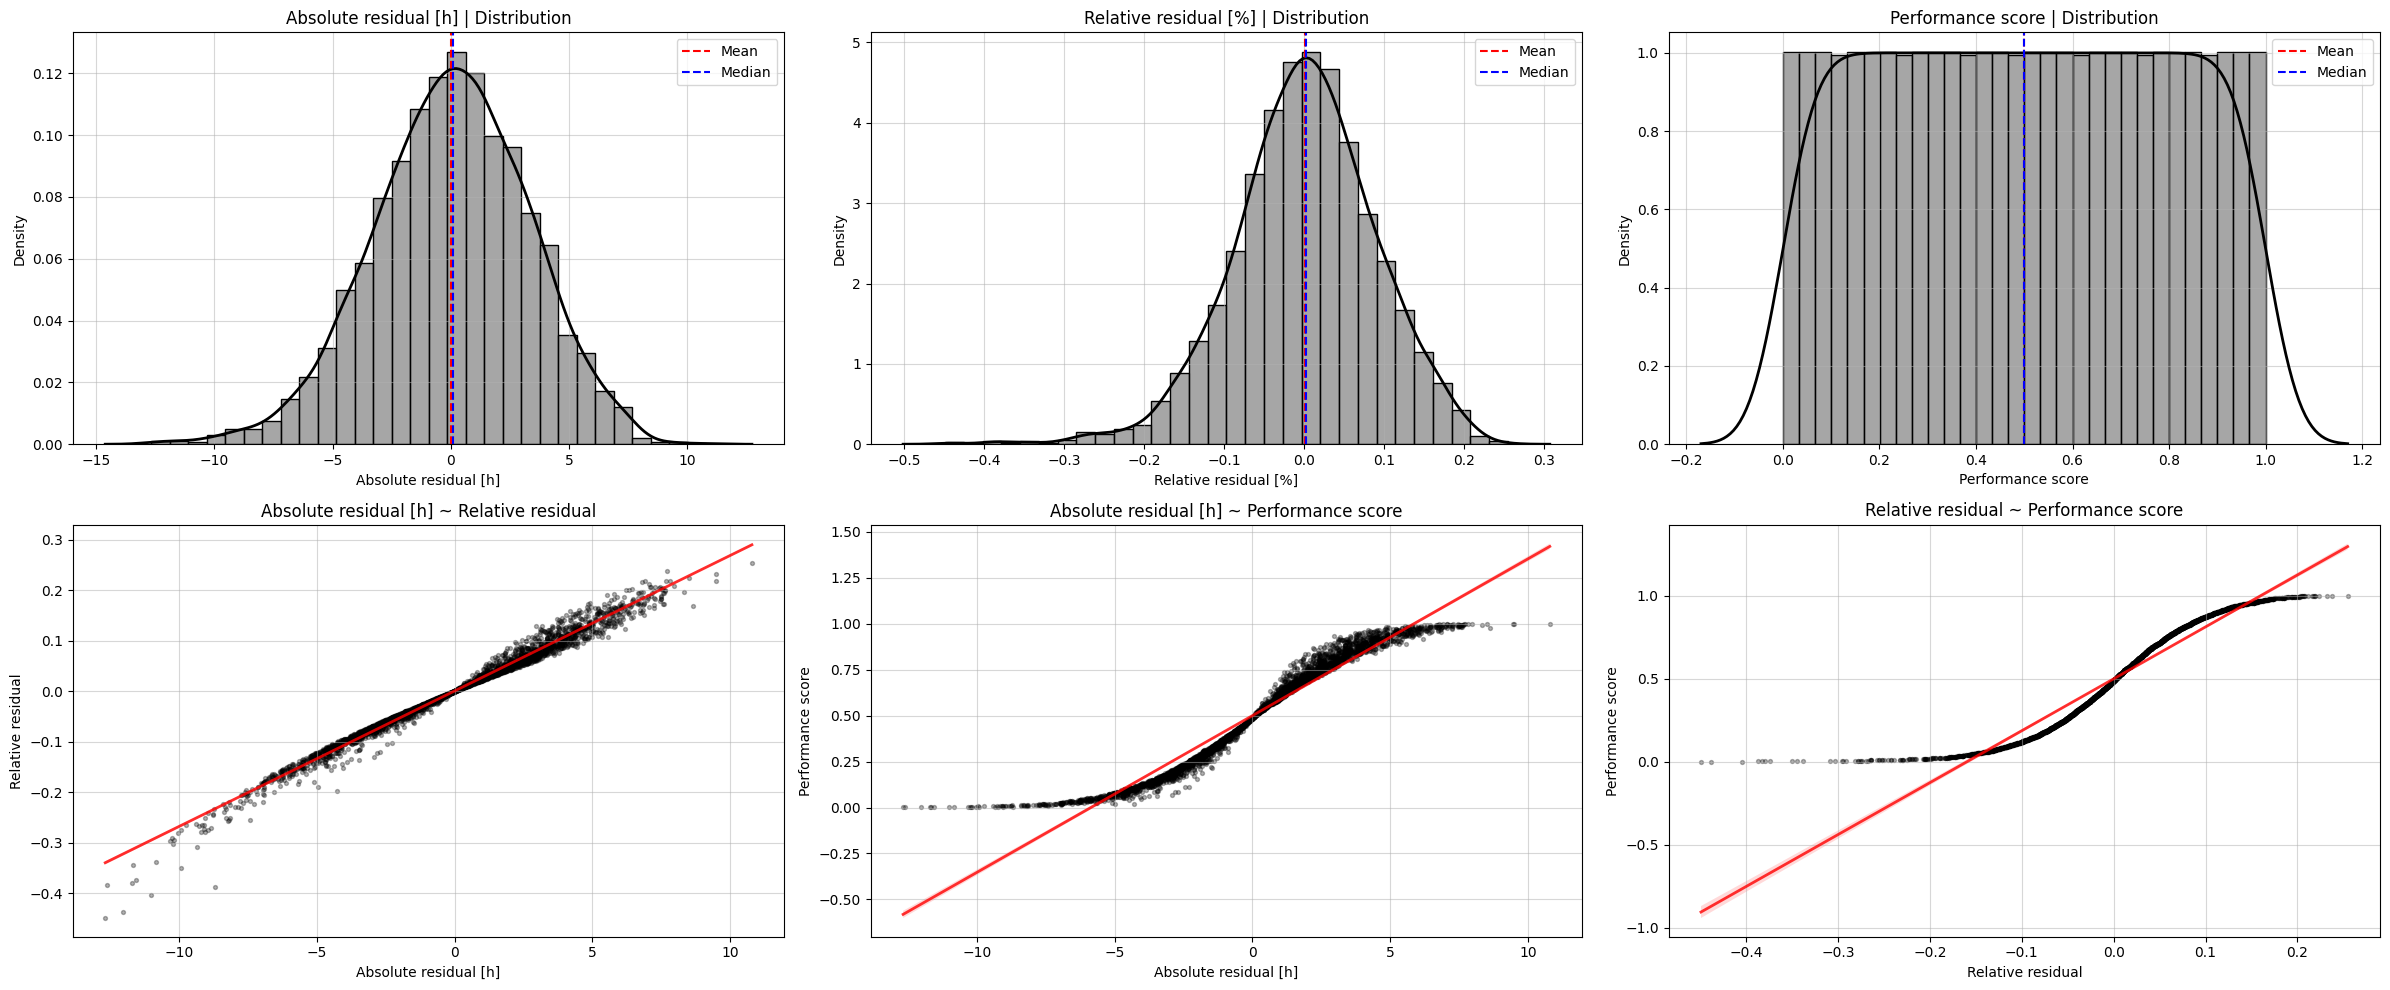

In [29]:
# Race time normalization diagnostics

plot_cols = [
    "runner_race_time_hours_residual_abs",
    "runner_race_time_hours_residual_prc",
    "runner_race_time_performance_score",
]

plot_titles = [
    "Absolute residual [h]",
    "Relative residual [%]",
    "Performance score",
]

scatter_pairs = [
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_hours_residual_prc",
        "Absolute residual [h]",
        "Relative residual",
    ),
    (
        "runner_race_time_hours_residual_abs",
        "runner_race_time_performance_score",
        "Absolute residual [h]",
        "Performance score",
    ),
    (
        "runner_race_time_hours_residual_prc",
        "runner_race_time_performance_score",
        "Relative residual",
        "Performance score",
    ),
]

fig, ax = plt.subplots(2, 3, figsize=(24, 10))

# Top row: distributions
for i, (col, title) in enumerate(zip(plot_cols, plot_titles)):
    sns.histplot(
        data=df_race_time_normalization_estimation,
        x=col,
        bins=30,
        stat="density",
        color="grey",
        edgecolor="black",
        alpha=0.7,
        ax=ax[0, i],
    )
    sns.kdeplot(
        data=df_race_time_normalization_estimation,
        x=col,
        color="black",
        linewidth=2,
        ax=ax[0, i],
    )

    ax[0, i].axvline(
        df_race_time_normalization_estimation[col].mean(),
        color="red",
        linestyle="--",
        label="Mean",
    )
    ax[0, i].axvline(
        df_race_time_normalization_estimation[col].median(),
        color="blue",
        linestyle="--",
        label="Median",
    )

    ax[0, i].set_title(f"{title} | Distribution")
    ax[0, i].set_xlabel(title)
    ax[0, i].set_ylabel("Density")
    ax[0, i].legend()

# Bottom row: relationships with actual race time
for i, (x_col, y_col, x_label, y_label) in enumerate(scatter_pairs):
    sns.regplot(
        data=df_race_time_normalization_estimation,
        x=x_col,
        y=y_col,
        scatter_kws={"color": "black", "s": 8, "alpha": 0.3},
        line_kws={"color": "red", "linewidth": 2, "alpha": 0.8},
        ax=ax[1, i],
    )

    ax[1, i].set_title(f"{x_label} ~ {y_label}")
    ax[1, i].set_xlabel(x_label)
    ax[1, i].set_ylabel(y_label)

for i in [0, 1]:
    for j in [0, 1, 2]:
        ax[i, j].grid(alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
# Merge back normalized race times to Finishers race time data
runner_race_sector_data_finisher_df = (
    runner_race_sector_data_finisher_df
    .merge(
        df_race_time_normalization_estimation[["runner_id", "runner_race_time_hours_residual_abs", "runner_race_time_hours_residual_prc", "runner_race_time_performance_score"]],
        on = "runner_id",
        how = "left",
    )
    .rename(columns={
        "runner_race_time_hours_residual_abs": "runner_race_time_hours_residual",
        "runner_race_time_hours_residual_prc": "runner_race_time_normalized",
        "runner_race_time_performance_score": "runner_rank_normalized",
    })
)


# Sector Time Normalization - Finishers & Movement time

What do we consider as sector time?
- a) movement into current checkpoint + rest at current checkpoint [sector_time_full_end_rest_min]
- b) previous checkpoint rest + movement into current checkpoint [sector_time_full_start_rest_min]
- c) movement only [sector_time_full_no_rest_min]

Decision: movement only [sector_time_full_no_rest_min]
- It measures movement from previous checkpoint departure to current checkpoint arrival.
- It is the cleanest signal for "how fast did the runner move through this sector?"
- Then we can analyze sector_rest_time_min separately as a rest/pacing strategy feature.
- Then we can also run a sensitivy version with: movement into current checkpoint + rest at current checkpoint [sector_time_full_end_rest_min]

Notes:
- Different years have different checkpoint ID 
    - We assigned sector_number {1,2, ..., N} within race/year.
    - sector_number - means relative order of sectors in that race/year

In [31]:
# Filter only for movement sectors
runner_race_sector_data_finisher_df = runner_race_sector_data_finisher_df.loc[~runner_race_sector_data_finisher_df["sector_is_rest_only"]].reset_index(drop=True)

In [32]:
# Race/Year sector times analysis

for (race_id, year), race_year_df in (
    runner_race_sector_data_df
    .sort_values(["race_id", "year", "sector_number"])
    .groupby(["race_id", "year"])
):
    sector_summary_df = (
        race_year_df
        .groupby("sector_number")
        .agg(
            sector_checkpoint_id = ("sector_checkpoint_id", "first"),
            n_runners = ("runner_id", "nunique"),
            distance_km = ("sector_distance_km", "first"),
            avg_movement_time_min = ("sector_time_full_no_rest_min", "mean"),
            avg_rest_time_min = ("sector_rest_time_min", "mean"),
        )
        .reset_index()
        .sort_values("sector_number")
    )

    print(f"Race/Year: {race_id} / {year}")
    print("-" * 60)
    print(f"- Number of sectors: {sector_summary_df['sector_number'].nunique():,}")
    print(f"- Number of runners: {race_year_df['runner_id'].nunique():,}")
    display(sector_summary_df)

    # print("- Average sector times:")
    # for _, row in sector_summary_df.iterrows():
    #     print("     - Sector {}".format(row["sector_number"]))
    #     print("         - Distance {:,.1f}".format(row["distance_km"]))
    #     print("         - Movement {:,.1f}".format(row["avg_movement_time_min"]))
    #     print("         - Rest {:,.1f}".format(row["avg_rest_time_min"]))
    #     print("         - Runners {:,.1f}".format(row["n_runners"]))
    print()

Race/Year: utmb / 2024
------------------------------------------------------------
- Number of sectors: 27
- Number of runners: 2,760


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,2760,13.190362,111.814966,0.000000
1,2,3,2760,8.489939,63.676772,0.049547
2,3,4,2760,9.659906,94.505385,3.870918
3,4,5,2760,4.280054,40.783834,0.041920
4,5,6,2760,4.370059,62.466769,0.052983
5,6,7,2760,5.830036,98.329727,0.003315
6,7,8,2760,5.279979,43.951425,14.638291
7,8,9,2760,10.790064,143.553935,0.068847
8,9,11,2760,7.330054,94.990319,1.182844
9,10,12,2760,4.000000,73.724449,0.001564



Race/Year: utmb / 2025
------------------------------------------------------------
- Number of sectors: 25
- Number of runners: 2,489


,sector_number,sector_checkpoint_id,n_runners,distance_km,avg_movement_time_min,avg_rest_time_min
0,1,2,2489,14.560041,123.756966,0.000000
1,2,3,2489,8.490028,62.684125,0.065120
2,3,4,2489,9.659864,90.363908,0.321762
3,4,6,2489,8.630009,107.523653,0.462595
4,5,7,2489,5.830004,104.091374,0.374849
5,6,8,2489,5.280000,58.635559,16.275425
6,7,9,2489,10.789980,145.265507,0.011437
7,8,11,2489,4.870184,57.989195,2.570202
8,9,12,2489,3.989994,74.654829,0.001513
9,10,13,2489,4.590060,45.647600,0.118046


### 1. Within-Runner normalization

- How each runner distributes their own moving race time
- Runner-relative sector allication - sector_time_full_no_rest_min / runner_total_moving_time_min [sector_pacing_absolute]

In [33]:
# Sector pacing Shares

runner_race_sector_data_finisher_df = (
    runner_race_sector_data_finisher_df
    .loc[lambda df: ~df["sector_is_rest_only"]]
    .assign(
        # Total moving time for each runner
        runner_total_moving_time_min = lambda df: (
            df.groupby("runner_id")["sector_time_full_no_rest_min"].transform("sum")
        ),

        # Runner-relative sector allocation
        sector_pacing_absolute = lambda df: (
            df["sector_time_full_no_rest_min"] / df["runner_total_moving_time_min"]
        ),
    )
)

# Check
assert np.isclose(
    runner_race_sector_data_finisher_df.groupby("runner_id")["sector_pacing_absolute"].sum(),
    1,
    atol = 1e-6
).all(), "sector_pacing_absolute does not sum to 1 for every runner."

display(
    runner_race_sector_data_finisher_df[[
            "runner_id",
            "race_id",
            "year",
            "sector_number",
            "sector_time_full_no_rest_min",
            "runner_total_moving_time_min",
            "sector_pacing_absolute",
    ]]
)


,runner_id,race_id,year,sector_number,sector_time_full_no_rest_min,runner_total_moving_time_min,sector_pacing_absolute
0,1,utmb,2024,1,72.700000,1312.933333,0.055372
1,1,utmb,2024,2,39.616667,1312.933333,0.030174
2,1,utmb,2024,3,54.500000,1312.933333,0.041510
3,1,utmb,2024,4,22.350000,1312.933333,0.017023
4,1,utmb,2024,5,35.500000,1312.933333,0.027039
...,...,...,...,...,...,...,...
82290,5249,utmb,2024,22,51.966667,1644.883333,0.031593
82291,5249,utmb,2024,23,62.833333,1644.883333,0.038199
82292,5249,utmb,2024,24,71.333333,1644.883333,0.043367
82293,5249,utmb,2024,26,136.183333,1644.883333,0.082792


### 2. Model-Based Sector Share Normalization

- Sector pacing normalization
- Expected sector share based on ability, year, and sector
- Did runner spend more/less of their race here than expected for this sector and ability?

In [34]:
# Data - one row per runner/sector
df_sector_pacing_normalization_estimation = (
    runner_race_sector_data_finisher_df
    [["runner_id", "race_id", "sector_pacing_absolute", "runner_overall_index", "year", "sector_number"]]
    .assign(
        runner_overall_index_centered = lambda df: (
            df["runner_overall_index"] - df["runner_overall_index"].mean()
        )
    )
    .dropna(how="any")
    .reset_index(drop=True)
    .copy()
)

In [35]:
# Model - Fit & Predict

# Fit 
model_sector_pacing_norm = smf.ols(
    formula = "sector_pacing_absolute ~ C(year):C(sector_number) + runner_overall_index_centered:C(sector_number)",
    data = df_sector_pacing_normalization_estimation,
)
fit_sector_pacing_norm = model_sector_pacing_norm.fit()

# Predict & store predictions
y_pred_sector_pacing_norm = fit_sector_pacing_norm.predict(df_sector_pacing_normalization_estimation)
df_sector_pacing_normalization_estimation["sector_pacing_absolute_pred"] = y_pred_sector_pacing_norm

# Sanity check
assert np.equal(
    df_sector_pacing_normalization_estimation["sector_pacing_absolute_pred"] <= 0,
    0
).all(), "there are some negative sector_pacing_absolute predictions"
assert np.equal(
    df_sector_pacing_normalization_estimation["sector_pacing_absolute_pred"] > 1,
    0
).all(), "there are some >1 sector_pacing_absolute predictions"

In [36]:
# Coefficients
coef_sector_pacing_norm_df = (
    pd.DataFrame({
        "coef": fit_sector_pacing_norm.params,
        "std_err": fit_sector_pacing_norm.bse,
        "p_value": fit_sector_pacing_norm.pvalues,
        "ci_lower": fit_sector_pacing_norm.conf_int()[0],
        "ci_upper": fit_sector_pacing_norm.conf_int()[1],
    })
    .reset_index(names="term")
    .assign(abs_coef = lambda df: df["coef"].abs())
)

display(
    coef_sector_pacing_norm_df
    .sort_values("abs_coef", ascending=False)
)

display(
    coef_sector_pacing_norm_df
    .sort_values("p_value")
)

,term,coef,std_err,p_value,ci_lower,ci_upper,abs_coef
44,C(year)[T.2025]:C(sector_number)[18],5.550031e-02,1.763336e-04,0.0000,5.515470e-02,5.584593e-02,5.550031e-02
0,Intercept,5.052247e-02,1.226219e-04,0.0000,5.028213e-02,5.076281e-02,5.052247e-02
45,C(year)[T.2025]:C(sector_number)[19],4.913187e-02,1.764044e-04,0.0000,4.878612e-02,4.947763e-02,4.913187e-02
33,C(year)[T.2025]:C(sector_number)[7],4.749368e-02,1.775288e-04,0.0000,4.714573e-02,4.784164e-02,4.749368e-02
46,C(year)[T.2025]:C(sector_number)[20],-4.218194e-02,1.763336e-04,0.0000,-4.252756e-02,-4.183633e-02,4.218194e-02
...,...,...,...,...,...,...,...
59,runner_overall_index_centered:C(sector_number)[6],3.473728e-08,9.206007e-07,0.9699,-1.769634e-06,1.839108e-06,3.473728e-08
38,C(year)[T.2025]:C(sector_number)[12],-1.164455e-16,1.221915e-18,0.0000,-1.188405e-16,-1.140506e-16,1.164455e-16
52,C(year)[T.2025]:C(sector_number)[26],4.099091e-17,1.241172e-19,0.0000,4.074764e-17,4.123418e-17,4.099091e-17
49,C(year)[T.2025]:C(sector_number)[23],-2.547412e-17,1.188505e-19,0.0000,-2.570707e-17,-2.524118e-17,2.547412e-17


,term,coef,std_err,p_value,ci_lower,ci_upper,abs_coef
0,Intercept,5.052247e-02,1.226219e-04,0.000000,0.050282,0.050763,5.052247e-02
1,C(sector_number)[T.2],-2.226762e-02,1.735129e-04,0.000000,-0.022608,-0.021928,2.226762e-02
2,C(sector_number)[T.3],-8.387656e-03,1.734360e-04,0.000000,-0.008728,-0.008048,8.387656e-03
3,C(sector_number)[T.4],-3.220232e-02,1.734137e-04,0.000000,-0.032542,-0.031862,3.220232e-02
4,C(sector_number)[T.5],-2.276849e-02,1.734137e-04,0.000000,-0.023108,-0.022429,2.276849e-02
...,...,...,...,...,...,...,...
69,runner_overall_index_centered:C(sector_number)...,-6.333070e-07,9.209557e-07,0.491667,-0.000002,0.000001,6.333070e-07
40,C(year)[T.2025]:C(sector_number)[14],7.815413e-05,1.763582e-04,0.657654,-0.000268,0.000424,7.815413e-05
78,runner_overall_index_centered:C(sector_number)...,2.722675e-07,1.309136e-06,0.835249,-0.000002,0.000003,2.722675e-07
55,runner_overall_index_centered:C(sector_number)[2],-4.801340e-08,9.207926e-07,0.958414,-0.000002,0.000002,4.801340e-08


Model diagnostics

In [37]:
# Does sector pacing predictions sum to 1 for every runner? If now, normalize them
display(
    df_sector_pacing_normalization_estimation
    .groupby("runner_id")
    [["sector_pacing_absolute", "sector_pacing_absolute_pred"]]
    .sum()
)

# Normalize
df_sector_pacing_normalization_estimation = (
    df_sector_pacing_normalization_estimation
    .assign(
        runner_sector_pacing_absolute_pred_sum = lambda df: (
            df.groupby(["race_id", "year", "runner_id"])
            ["sector_pacing_absolute_pred"]
            .transform("sum")
        ),
        sector_pacing_absolute_pred = lambda df: (
            df["sector_pacing_absolute_pred"]
            / df["runner_sector_pacing_absolute_pred_sum"]
        ),
    )
)

# Check
sector_pacing_share_check_df = (
    df_sector_pacing_normalization_estimation
    .groupby(["race_id", "year", "runner_id"])
    .agg(
        sector_pacing_absolute_sum = ("sector_pacing_absolute", "sum"),
        sector_pacing_absolute_pred_sum = ("sector_pacing_absolute_pred", "sum"),
    )
    .reset_index()
)

assert np.allclose(
    sector_pacing_share_check_df["sector_pacing_absolute_sum"],
    1,
    atol = 1e-6,
), "Actual sector pacing shares do not sum to 1 for every runner."

assert np.allclose(
    sector_pacing_share_check_df["sector_pacing_absolute_pred_sum"],
    1,
    atol = 1e-6,
), "Predicted sector pacing shares do not sum to 1 for every runner."

,sector_pacing_absolute,sector_pacing_absolute_pred
runner_id,,
1,1.0,1.002178
2,1.0,0.997280
4,1.0,0.998259
5,1.0,1.002048
11,1.0,1.002513
...,...,...
5242,1.0,1.000507
5243,1.0,1.001561
5245,1.0,1.001267


In [38]:
# Calculate absolute sector pacing residual: Expected - Actual
df_sector_pacing_normalization_estimation = (
    df_sector_pacing_normalization_estimation
    .assign(
        sector_pacing_absolute_residual_abs = lambda df: (
            df["sector_pacing_absolute_pred"] - df["sector_pacing_absolute"]
        )
    )
)

Sector pace normalization - description of runner's pace in that specific sector
- Sector pacing absolute [sector_pacing_absolute]
    - What fraction of this runner’s total moving race time was spent in this sector?
    - 0.08 --> This sector took 8% of the runner's total moving race time.
    - It is runner-relative. It does not say if that moving time is good or bad by itself.
- Predicted sector pacing absolute [sector_pacing_absolute_pred]
    - For a runner with this UTMB index, in this year, in this sector, what share of total moving race time would we expect this sector to take?
- Absolute residual [sector_pacing_absolute_residual_abs or sector_pacing_absolute_residual_abs]
    - Expected sector share - Actual sector share 
    - How much less/more race share did this runner spend in this sector than expected?
    - 0.05 -> runner spent 5 percentage points less of their race in this sector than expected.
    - They were relatively strong/fast/aggressive in this sector.
- Relative residual [sector_pacing_absolute_residual_prc or sector_pacing_normalized]
    - 1 - Actual sector share / Expected sector share
    - Percentage difference from expected sector share
    - 0.2 -> runner spent 20% less in this sector than expected.
- Percentile residual Overall [sector_pacing_performance_score_overall or sector_pacing_rank_overall_normalized]
    - 1 - Relative residual ranked by percentages across all races, years, sectors
    - Percentile rank of sector_pacing_normalized across all runner-sector observations.
    - 0.1 -> runner relative share was lower than 90% of runner-sector observations across all races, years, sectors
- Percentile residual Specific [sector_pacing_performance_score_specific or sector_pacing_rank_overall_specific]
    - 1 - Relative residual ranked by percentages within race/year/sector
    - Percentile rank of sector_pacing_normalized within the same race/year/sector.
    - 0.1 -> runner relative share was lower than 90% of runners in the same race/year/sector

In [39]:
# Normalize sector pacing - Residual based
df_sector_pacing_normalization_estimation = (
    df_sector_pacing_normalization_estimation
    .assign(
        sector_pacing_absolute_residual_prc = lambda df: (
           1 - df["sector_pacing_absolute"] / df["sector_pacing_absolute_pred"]
        ),
        sector_pacing_performance_score_overall = lambda df: (
            df["sector_pacing_absolute_residual_prc"].rank(pct=True)
        ),
        sector_pacing_performance_score_specific = lambda df: (
            df.groupby(["race_id", "year", "sector_number"])
            ["sector_pacing_absolute_residual_prc"].rank(pct = True)
        )
    )
)

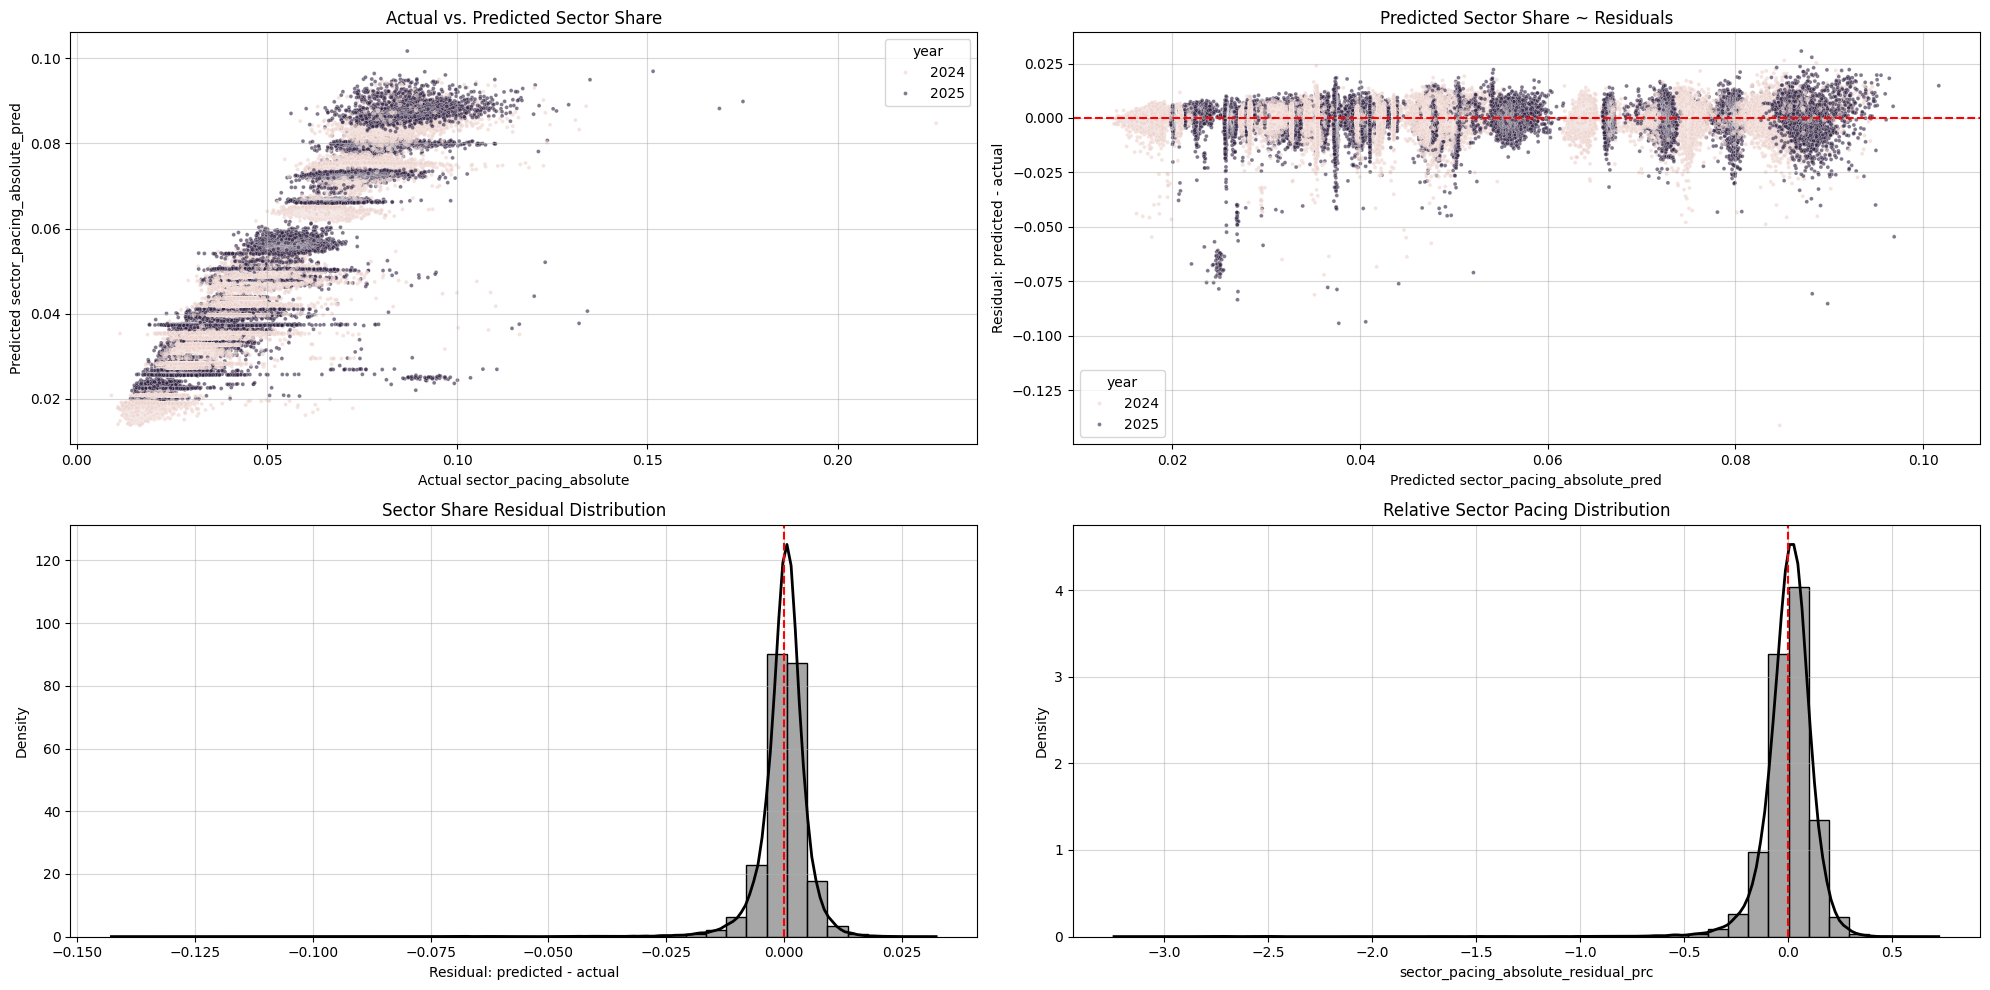

In [40]:
# Sector pacing diagnostics

fig, ax = plt.subplots(2, 2, figsize = (20, 10))

# Actual vs predicted
sns.scatterplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute",
    y = "sector_pacing_absolute_pred",
    hue = "year",
    s = 8,
    alpha = 0.6,
    ax = ax[0,0],
)
ax[0,0].set_title("Actual vs. Predicted Sector Share")
ax[0,0].set_xlabel("Actual sector_pacing_absolute")
ax[0,0].set_ylabel("Predicted sector_pacing_absolute_pred")

# Predicted vs residuals
sns.scatterplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute_pred",
    y = "sector_pacing_absolute_residual_abs",
    hue = "year",
    s = 8,
    alpha = 0.6,
    ax = ax[0,1],
    legend = True,
)
ax[0,1].axhline(0, color = "red", linestyle = "--")
ax[0,1].set_title("Predicted Sector Share ~ Residuals")
ax[0,1].set_xlabel("Predicted sector_pacing_absolute_pred")
ax[0,1].set_ylabel("Residual: predicted - actual")

# Residual distribution
sns.histplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute_residual_abs",
    bins = 40,
    stat = "density",
    color = "grey",
    edgecolor = "black",
    alpha = 0.7,
    ax = ax[1,0],
)
sns.kdeplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute_residual_abs",
    color = "black",
    linewidth = 2,
    ax = ax[1,0],
)
ax[1,0].axvline(0, color = "red", linestyle = "--")
ax[1,0].set_title("Sector Share Residual Distribution")
ax[1,0].set_xlabel("Residual: predicted - actual")

# Relative normalized sector pacing distribution
sns.histplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute_residual_prc",
    bins = 40,
    stat = "density",
    color = "grey",
    edgecolor = "black",
    alpha = 0.7,
    ax = ax[1,1],
)
sns.kdeplot(
    data = df_sector_pacing_normalization_estimation,
    x = "sector_pacing_absolute_residual_prc",
    color = "black",
    linewidth = 2,
    ax = ax[1,1],
)
ax[1,1].axvline(0, color = "red", linestyle = "--")
ax[1,1].set_title("Relative Sector Pacing Distribution")
ax[1,1].set_xlabel("sector_pacing_absolute_residual_prc")

for i in [0, 1]:
    for j in [0, 1]:
        ax[i,j].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

In [41]:
# Merge back normalized sector pacing to Finishers race time data
runner_race_sector_data_finisher_df = (
    runner_race_sector_data_finisher_df
    .merge(
        df_sector_pacing_normalization_estimation[["runner_id", "sector_number", "sector_pacing_absolute_pred", "sector_pacing_absolute_residual_abs", "sector_pacing_absolute_residual_prc", "sector_pacing_performance_score_overall", "sector_pacing_performance_score_specific"]],
        on = ["runner_id", "sector_number"],
        how = "left",
    )
    .rename(columns={
        "sector_pacing_absolute_residual_abs": "sector_pacing_absolute_residual",
        "sector_pacing_absolute_residual_prc": "sector_pacing_normalized",
        "sector_pacing_performance_score_overall": "sector_pacing_rank_overall_normalized",
        "sector_pacing_performance_score_specific": "sector_pacing_rank_specific_normalized"
    })
)


Define "race progress"
- Each year has different number of sector, and they do not represent the same race position every year.
- Distance based progress: Cumulative distance at sector / Total distance
- Race phase based on distance
    - Very early: 0–1/5
    - Early: 1/5–2/5
    - Middle: 2/5–3/5
    - Late: 3/5–4/5
    - Very late: 4/5–1

In [ ]:
# Define race phases - 5
race_phase_bins, race_phase_labels = (
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    ["very_early", "early", "middle", "late", "very_late"],
)

runner_race_sector_data_finisher_df = (
    runner_race_sector_data_finisher_df
    .assign(
        race_phase = lambda df: pd.cut(
            df["relative_cumulative_sector_distance"],
            bins = race_phase_bins,
            labels =race_phase_labels,
            include_lowest = True,
        ),
        race_phase_time_min = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_time_moving_min"]
            .transform("sum")
        ),
        race_phase_distance_km = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_distance_km"]
            .transform("sum")
        ),
        race_phase_elevation_gain_m = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_elevation_gain_m"]
            .transform("sum")
        ),
        race_phase_elevation_loss_m = lambda df: (
            df.groupby(["runner_id", "year", "race_phase"], observed = True)["sector_elevation_loss_m"]
            .transform("sum")
        ),
    )
)

1. Within-Runner "normalization"
    - "How did this runner distribute their own race across sectors?"
    - sector_pacing_absolute = sector_time_full_no_rest_min / runner_total_moving_time
      (runner-relative allocation)
        - sector 0: 5.2% of their race
        - sector 1: 3.8% of their race
        - sector 2: 6.1% of their race
        - sum(sector_pacing_absolute) = 1
    - This removes total race speed, but does not yet adjust for ability, year, or sector-specific effects.

2. Model-Based Sector Share Normalization
    - "Given this runner's UTMB index, race year, and sector, how much of their race would we expect them to spend in this sector?"
    - Model:
        - sector_pacing_absolute ~ runner_overall_index + C(year) + C(sector_number)
          + runner_overall_index:C(sector_number)
          + C(year):C(sector_number)
    - sector_pacing_expected = model-predicted sector_pacing_absolute
    - sector_pacing_relative = 1 - sector_pacing_absolute / sector_pacing_expected
    - Interpretation:
        - sector_pacing_relative > 0: runner spent less share than expected in this sector
        - sector_pacing_relative = 0: runner was close to expected
        - sector_pacing_relative < 0: runner spent more share than expected in this sector
        - higher value = relatively better/faster sector allocation
    - This gives us a sector pacing value adjusted for:
        - runner ability
        - year/course conditions
        - sector position/difficulty
        - ability differences by sector
        - year differences by sector

3. Runner-Level Pacing Features
    - "What kind of pacing profile did this runner have?"
    - Use sector_pacing_relative values across sectors to summarize the shape of the race.
    - Possible features:
        - early_pacing = average sector_pacing_relative in early sectors
        - middle_pacing = average sector_pacing_relative in middle sectors
        - late_pacing = average sector_pacing_relative in late sectors
        - fade_score = late_pacing - early_pacing
        - pacing_variability = standard deviation of sector_pacing_relative across sectors
    - Interpretation:
        - high early_pacing = runner spent less time than expected in early sectors
        - high late_pacing = runner spent less time than expected in late sectors
        - fade_score > 0 = relatively stronger late than early
        - fade_score < 0 = relatively weaker late than early
        - high pacing_variability = uneven pacing profile

4. Compare Pacing Features With Normalized Race Outcome
    - "Which pacing profiles are associated with better race performance?"
    - Outcome:
        - runner_race_time_normalized
        - higher = better race result relative to expected race time
    - Example questions:
        - Do runners with high early_pacing perform better or worse?
        - Do runners with negative fade_score perform worse?
        - Is low pacing_variability associated with better race outcomes?
        - Are strong late sectors more predictive than strong early sectors?
    - Example model idea:
        - runner_race_time_normalized ~ early_pacing + fade_score + pacing_variability

5. Sensitivity Analysis With Rest
    - "Do conclusions change if rest/aid-station time is included?"
    - Repeat the same process with:
        - sector_time_full_end_rest_min
    - Compare against the movement-only version:
        - sector_time_full_no_rest_min
    - This tells us whether race outcome is more linked to moving pace, rest strategy, or both.

In [43]:
# About race phases
race_phases_summary = (
    runner_race_sector_data_finisher_df
    .groupby(["race_id", "year", "race_phase"], observed = True)
    .agg(
        number_of_sectors = ("sector_number", "nunique"),
        number_of_runners = ("runner_id", "nunique"),
        number_of_observations = ("runner_id", "size"),
        avg_time_min = ("race_phase_time_min", "mean"),
        total_distance_km = ("race_phase_distance_km", "mean"),
        total_elevation_gain = ("race_phase_elevation_gain_m", "mean"),
        total_elevation_loss = ("race_phase_elevation_loss_m", "mean"),
        from_sector = ("sector_number", "min"),
        to_sector = ("sector_number", "max"),
    )
    .reset_index()
)

for (race_id, year), df in race_phases_summary.groupby(["race_id", "year"]):
    print("\n{} - {}:".format(race_id, year))
    print("-------------------------------------------")
    for _, row in df.iterrows():
        avg_minutes = row["avg_time_min"]
        total_seconds = int(round(avg_minutes * 60))
        hours, remainder = divmod(total_seconds, 3600)
        minutes, seconds = divmod(remainder, 60)

        print(" - {}".format(row["race_phase"]))
        print("   - number of sectors: {:,}".format(row["number_of_sectors"]))
        print("   - number of runners: {:,}".format(row["number_of_runners"]))
        print("   - average time: {:,.2f} min ({:02d}:{:02d}:{:02d})".format(avg_minutes, hours, minutes, seconds))
        print("   - total distance: {:,.2f} km".format(row["total_distance_km"]))
        print("   - total elevation gain: {:,.2f} m".format(row["total_elevation_gain"]))
        print("   - total elevation loss: {:,.2f} m".format(row["total_elevation_loss"]))
        print("   - from: {}, to: {}".format(row["from_sector"], row["to_sector"]))


utmb - 2024:
-------------------------------------------
 - very_early
   - number of sectors: 3
   - number of runners: 1,760
   - average time: 262.42 min (04:22:25)
   - total distance: 31.34 km
   - total elevation gain: 1,669.98 m
   - total elevation loss: 1,626.83 m
   - from: 1, to: 3
 - early
   - number of sectors: 6
   - number of runners: 1,760
   - average time: 467.59 min (07:47:35)
   - total distance: 37.88 km
   - total elevation gain: 2,838.75 m
   - total elevation loss: 1,796.15 m
   - from: 4, to: 9
 - middle
   - number of sectors: 7
   - number of runners: 1,760
   - average time: 501.22 min (08:21:13)
   - total distance: 36.62 km
   - total elevation gain: 2,524.70 m
   - total elevation loss: 2,471.10 m
   - from: 10, to: 17
 - late
   - number of sectors: 4
   - number of runners: 1,760
   - average time: 428.88 min (07:08:53)
   - total distance: 35.15 km
   - total elevation gain: 1,570.72 m
   - total elevation loss: 2,225.32 m
   - from: 18, to: 21
 - ve

### 3. Pacing analysis

In [44]:
# Main dataframe for analysis
pacing_df = runner_race_sector_data_finisher_df[[
    # Identifiers
    "race_id", "year", "runner_id", 
    # Runner ability
    "runner_overall_index",
    # Normalized final race outcome
    "runner_race_time_normalized", "runner_rank_normalized",
    # Sector id
    "sector_number", "sector_checkpoint_id",
    # Sector distance
    "sector_distance_km", "relative_sector_distance",
    "sector_start_distance_km", "sector_end_distance_km",
    "relative_sector_start_distance", "relative_sector_end_distance",
    # Sector elevation gain
    "sector_elevation_gain_m", "relative_sector_elevation_gain",
    "sector_start_elevation_gain_m", "sector_end_elevation_gain_m",
    "relative_sector_start_elevation_gain", "relative_sector_end_elevation_gain",
    # Sector elevation loss
    "sector_elevation_loss_m", "relative_sector_elevation_loss",
    "sector_start_elevation_loss_m", "sector_end_elevation_loss_m",
    "relative_sector_start_elevation_loss", "relative_sector_end_elevation_loss",
    # Race progress
    "cumulative_sector_distance_km", "relative_cumulative_sector_distance", "race_phase",
    # Absolute sector pacing
    "sector_pacing_absolute", "sector_pacing_absolute_pred", 
    # Normalized sector pacing
    "sector_pacing_normalized", "sector_pacing_rank_overall_normalized", "sector_pacing_rank_specific_normalized",
]].copy()

display(pacing_df)

,race_id,year,runner_id,runner_overall_index,runner_race_time_normalized,runner_rank_normalized,sector_number,sector_checkpoint_id,sector_distance_km,relative_sector_distance,...,relative_sector_start_elevation_loss,relative_sector_end_elevation_loss,cumulative_sector_distance_km,relative_cumulative_sector_distance,race_phase,sector_pacing_absolute,sector_pacing_absolute_pred,sector_pacing_normalized,sector_pacing_rank_overall_normalized,sector_pacing_rank_specific_normalized
0,utmb,2024,1,831.0,0.122860,0.918840,1,2,13.190362,0.074644,...,0.000000,0.039076,13.190362,0.074644,very_early,0.055372,0.053310,-0.038679,0.289061,0.317614
1,utmb,2024,1,831.0,0.122860,0.918840,2,3,8.489939,0.048044,...,0.039076,0.128564,21.680301,0.122688,very_early,0.030174,0.028181,-0.070733,0.192630,0.184510
2,utmb,2024,1,831.0,0.122860,0.918840,3,4,9.659906,0.054665,...,0.128564,0.154810,31.340207,0.177353,very_early,0.041510,0.042351,0.019866,0.541089,0.612848
3,utmb,2024,1,831.0,0.122860,0.918840,4,5,4.280054,0.024221,...,0.154810,0.162237,35.620261,0.201574,early,0.017023,0.016813,-0.012516,0.393053,0.419886
4,utmb,2024,1,831.0,0.122860,0.918840,5,6,4.370059,0.024730,...,0.162237,0.162769,39.990320,0.226304,early,0.027039,0.028496,0.051128,0.681503,0.703409
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
82290,utmb,2024,5249,656.0,0.164447,0.971872,22,31,5.200000,0.029427,...,0.772643,0.799792,146.190476,0.827288,very_late,0.031593,0.033573,0.058966,0.714493,0.659659
82291,utmb,2024,5249,656.0,0.164447,0.971872,23,33,4.000000,0.022636,...,0.799792,0.830510,150.190476,0.849924,very_late,0.038199,0.036119,-0.057608,0.227721,0.224687
82292,utmb,2024,5249,656.0,0.164447,0.971872,24,34,8.150043,0.046121,...,0.830510,0.884295,158.340519,0.896045,very_late,0.043367,0.050179,0.135760,0.921072,0.857224
82293,utmb,2024,5249,656.0,0.164447,0.971872,26,44,11.280022,0.063833,...,0.884295,0.975173,169.620540,0.959878,very_late,0.082792,0.087240,0.050983,0.680807,0.692614


In [45]:
# Some checks
assert not pacing_df.duplicated(
    ["runner_id", "sector_number"]
).any(), "Duplicate runner-sector observations found."

# Some values are missing - only because of runners missing UTMB index - we remove this values for the analysis
pacing_df = (
    pacing_df
    .loc[lambda df: df["runner_overall_index"].notna()]
    .loc[lambda df: df["sector_pacing_absolute"].notna()] # needs to be checked
    .reset_index(drop = True)
)

# Only sector checkpoint id 15 (sector number 12 has missing distance values)
display(pacing_df.isna().sum())
assert not pacing_df.isna().any().any(), "Some values are still missing."

race_id                                   0
year                                      0
runner_id                                 0
runner_overall_index                      0
runner_race_time_normalized               0
runner_rank_normalized                    0
sector_number                             0
sector_checkpoint_id                      0
sector_distance_km                        0
relative_sector_distance                  0
sector_start_distance_km                  0
sector_end_distance_km                    0
relative_sector_start_distance            0
relative_sector_end_distance              0
sector_elevation_gain_m                   0
relative_sector_elevation_gain            0
sector_start_elevation_gain_m             0
sector_end_elevation_gain_m               0
relative_sector_start_elevation_gain      0
relative_sector_end_elevation_gain        0
sector_elevation_loss_m                   0
relative_sector_elevation_loss            0
sector_start_elevation_loss_m   

One row per runner-sector -> one row per runner-race phase [aggregation]

In [55]:
# Aggregation per race-phases

pacing_race_phase_agg_df = (
    pacing_df
    .sort_values(["race_id", "year", "runner_id", "sector_number"])
    .groupby(
        ["race_id", "year", "runner_id", "race_phase"],
        observed = True,
        as_index = False,
    )
    .agg(
        # Runner information
        runner_overall_index = ("runner_overall_index", "first"),

        # Final race outcome
        runner_race_time_normalized = ("runner_race_time_normalized", "first"),
        runner_rank_normalized = ("runner_rank_normalized", "first"),

        # Phase sectors
        phase_sector_ids = ("sector_checkpoint_id", "unique"),
        phase_first_sector_number = ("sector_number", "first"),
        phase_last_sector_number = ("sector_number", "last"),
        phase_number_of_sectors = ("sector_number", "nunique"),

        # Phase distance
        phase_distance_km = ("sector_distance_km", "sum"),
        phase_relative_distance = ("relative_sector_distance", "sum"),
        phase_start_distance_km = ("sector_start_distance_km", "first"),
        phase_end_distance_km = ("sector_end_distance_km", "last"),
        phase_relative_start_distance = ("relative_sector_start_distance", "first"),
        phase_relative_end_distance = ("relative_sector_end_distance", "last"),

        # Phase elevation gain
        phase_elevation_gain_m = ("sector_elevation_gain_m", "sum"),
        phase_relative_elevation_gain = ("relative_sector_elevation_gain", "sum"),
        phase_start_elevation_gain_m = ("sector_start_elevation_gain_m", "first"),
        phase_end_elevation_gain_m = ("sector_end_elevation_gain_m", "last"),
        phase_relative_start_elevation_gain = ("relative_sector_start_elevation_gain", "first"),
        phase_relative_end_elevation_gain = ("relative_sector_end_elevation_gain", "last"),

        # Phase elevation loss
        phase_elevation_loss_m = ("sector_elevation_loss_m", "sum"),
        phase_relative_elevation_loss = ("relative_sector_elevation_loss", "sum"),
        phase_start_elevation_loss_m = ("sector_start_elevation_loss_m", "first"),
        phase_end_elevation_loss_m = ("sector_end_elevation_loss_m", "last"),
        phase_relative_start_elevation_loss = ("relative_sector_start_elevation_loss", "first"),
        phase_relative_end_elevation_loss = ("relative_sector_end_elevation_loss", "last"),

        # Actual and expected race-time share
        phase_pacing_absolute = ("sector_pacing_absolute", "sum"),
        phase_pacing_expected = ("sector_pacing_absolute_pred", "sum"),
    )
    .assign(
        # Same as for sector pacing, but now for phase pacing, as sectors are not equally "long"
        phase_pacing_normalized = lambda df: (
            1 - df["phase_pacing_absolute"] / df["phase_pacing_expected"]
        )
    )
    .reset_index(drop=True)
    .assign(
        race_phase = lambda df: pd.Categorical(
            df["race_phase"],
            categories = race_phase_labels,
            ordered = True,
        )
    )
)

display(pacing_race_phase_agg_df)

# Assertions
assert not pacing_race_phase_agg_df.isnull().any().any(), "Some pacing values are still missing."

phase_share_sum = (
    pacing_race_phase_agg_df
    .groupby("runner_id")["phase_pacing_absolute"]
    .sum()
)

assert np.allclose(
    pacing_race_phase_agg_df.groupby("runner_id")["phase_pacing_absolute"].sum(),
    1,
    atol = 1e-6,
), "Phase pacing shares do not sum to 1 for every runner."

,race_id,year,runner_id,race_phase,runner_overall_index,runner_race_time_normalized,runner_rank_normalized,phase_sector_ids,phase_first_sector_number,phase_last_sector_number,...,phase_relative_end_elevation_gain,phase_elevation_loss_m,phase_relative_elevation_loss,phase_start_elevation_loss_m,phase_end_elevation_loss_m,phase_relative_start_elevation_loss,phase_relative_end_elevation_loss,phase_pacing_absolute,phase_pacing_expected,phase_pacing_normalized
0,utmb,2024,1,very_early,831.0,0.122860,0.91884,"[2, 3, 4]",1,3,...,0.158901,1626.832005,0.154810,0.000000,1626.832005,0.000000,0.154810,0.127056,0.123843,-0.025952
1,utmb,2024,1,early,831.0,0.122860,0.91884,"[5, 6, 7, 8, 9, 11]",4,9,...,0.429013,1796.146896,0.170922,1626.832005,3422.978901,0.154810,0.325731,0.216056,0.211896,-0.019628
2,utmb,2024,1,middle,831.0,0.122860,0.91884,"[12, 13, 14, 18, 19, 20, 22]",10,17,...,0.669242,2471.100000,0.235150,3422.978901,5894.078901,0.325731,0.560882,0.231441,0.228337,-0.013596
3,utmb,2024,1,late,831.0,0.122860,0.91884,"[23, 24, 27, 30]",18,21,...,0.818698,2225.317366,0.211762,5894.078901,8119.396268,0.560882,0.772643,0.184472,0.184711,0.001291
4,utmb,2024,1,very_late,831.0,0.122860,0.91884,"[31, 33, 34, 44, 144]",22,27,...,1.000000,2389.200000,0.227357,8119.396268,10508.596268,0.772643,1.000000,0.240974,0.251214,0.040759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17060,utmb,2025,4915,very_early,489.0,-0.041162,0.29915,"[2, 3, 4]",1,3,...,0.162825,1626.832005,0.163066,0.000000,1626.832005,0.000000,0.163066,0.127046,0.132126,0.038442
17061,utmb,2025,4915,early,489.0,-0.041162,0.29915,"[6, 7, 8, 11]",4,8,...,0.422051,1488.900000,0.149240,1626.832005,3344.932005,0.163066,0.335279,0.225464,0.153859,-0.465399
17062,utmb,2025,4915,middle,489.0,-0.041162,0.29915,"[12, 13, 14, 18, 19, 20, 22]",9,16,...,0.668212,2471.100000,0.247691,3344.932005,5816.032005,0.335279,0.582970,0.219379,0.238557,0.080395
17063,utmb,2025,4915,late,489.0,-0.041162,0.29915,"[24, 27, 30]",17,19,...,0.814221,1771.317366,0.177548,5816.032005,7587.349372,0.582970,0.760518,0.193616,0.215045,0.099652


Divide runners into performance groups [runner_rank_normalized]

In [ ]:
# Divide runners into performance groups based on runner_rank_normalized
runner_performance_group_bins, runner_performance_group_labels = (
    [0, 0.2, 0.4, 0.6, 0.8, 1],
    ["very_slow", "slow", "middle", "fast", "very_fast"],
)

pacing_race_phase_agg_df = (
    pacing_race_phase_agg_df
    .assign(
        runner_performance_group = lambda df: pd.cut(
            df["runner_rank_normalized"],
            bins = runner_performance_group_bins,
            labels = runner_performance_group_labels,
            include_lowest = True,
        ),
    )
)

# About
performance_group_pacing_summary_df = (
    pacing_race_phase_agg_df
    .groupby(
        ["runner_performance_group", "race_phase"],
        observed = True,
        as_index = False,
    )
    .agg(
        number_of_runners = ("runner_id", "nunique"),
        phase_pacing_mean = ("phase_pacing_normalized", "mean"),
        phase_pacing_median = ("phase_pacing_normalized", "median"),
        phase_pacing_std = ("phase_pacing_normalized", "std"),
    )
)


display(performance_group_pacing_summary_df)

,runner_performance_group,race_phase,number_of_runners,phase_pacing_mean,phase_pacing_median,phase_pacing_std
0,very_slow,very_early,682,0.048678,0.047467,0.078732
1,very_slow,early,682,0.011628,0.020128,0.095732
2,very_slow,middle,682,-0.000458,-0.000888,0.062300
3,very_slow,late,682,-0.028497,-0.026424,0.067492
4,very_slow,very_late,682,-0.014066,0.002911,0.110304
5,slow,very_early,683,0.012587,0.013729,0.074286
6,slow,early,683,0.008695,0.015202,0.073602
7,slow,middle,683,-0.002649,-0.001228,0.052245
8,slow,late,683,-0.011871,-0.009518,0.058649
9,slow,very_late,683,-0.003912,0.001965,0.084761


---
---
Notes:
- Pacing strategy:
    - normalized race outcome ~ pacing strategy
    - runner_race_time_residual_rel ~ early_pace + fade_score + pacing_variability